In [1]:
import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

In [2]:
import OptLinearRegress
from OptLinearRegress import LinearRegressor

from sklearn.linear_model import LinearRegression
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools
import time

Imported package successfully


In [3]:
dir(OptLinearRegress)

['DoubleArray',
 'LinearRegressor',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'add_intercept',
 'batch_iterator',
 'data',
 'explained_variance_score',
 'linalg',
 'linear_model',
 'math',
 'mean_absolute_error',
 'mean_squared_error',
 'memory',
 'metrics',
 'models',
 'normal_equation',
 'r2_score',
 'random',
 'root_mean_squared_error',
 'shuffle_arrays',
 'solve_normal_equation',
 'solvers',
 'standardize',
 'train_test_split',
 'utils']


Benchmarking for n_features = 5
Samples:      100 | Cython:    0.011 ms | Sklearn:    1.826 ms
Samples:     1000 | Cython:    0.030 ms | Sklearn:    0.507 ms
Samples:     5000 | Cython:    0.260 ms | Sklearn:    1.851 ms
Samples:    10000 | Cython:    0.567 ms | Sklearn:    2.945 ms
Samples:    50000 | Cython:    2.353 ms | Sklearn:   11.318 ms
Samples:   100000 | Cython:    6.606 ms | Sklearn:   25.116 ms
Samples:   500000 | Cython:   26.170 ms | Sklearn:  111.460 ms
Samples:  1000000 | Cython:   90.879 ms | Sklearn:  251.700 ms

Benchmarking for n_features = 10
Samples:      100 | Cython:    0.244 ms | Sklearn:    0.525 ms
Samples:     1000 | Cython:    0.067 ms | Sklearn:    0.904 ms
Samples:     5000 | Cython:    0.452 ms | Sklearn:    1.910 ms
Samples:    10000 | Cython:    0.888 ms | Sklearn:    3.453 ms
Samples:    50000 | Cython:    9.672 ms | Sklearn:   18.697 ms
Samples:   100000 | Cython:   16.165 ms | Sklearn:   38.358 ms
Samples:   500000 | Cython:  160.901 ms | Sklearn: 

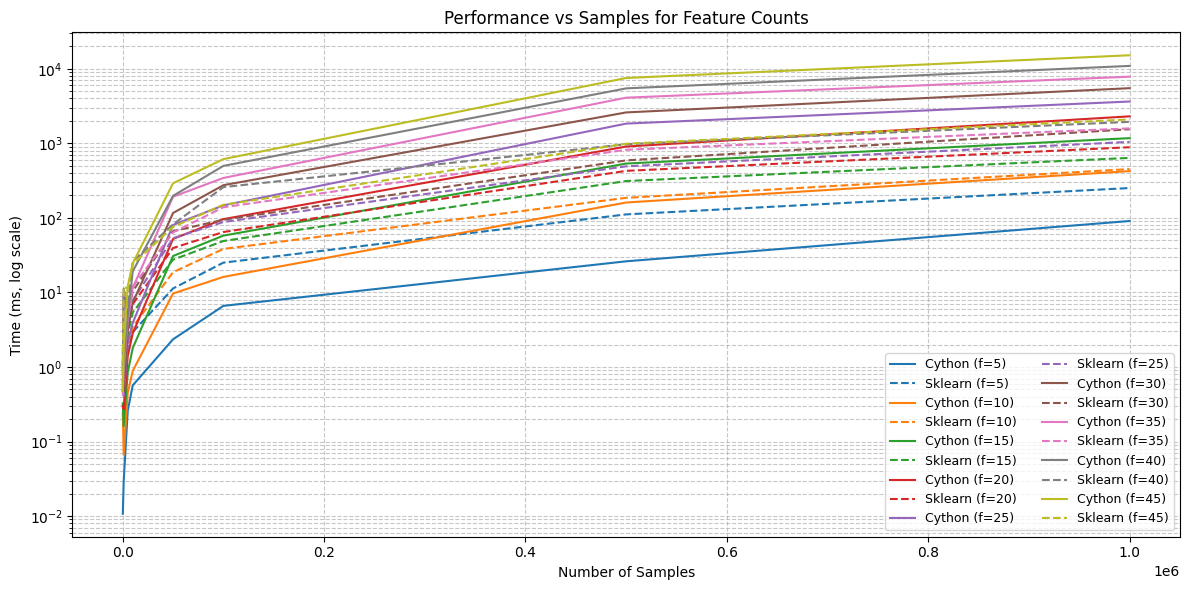

In [6]:
random.seed(42)

def generate_data(n_samples, n_features):
    """
    Generate linear data: y = sum(weights * x_i) + noise
    Weights: 1, 2, ..., n_features
    """
    X = []
    y = []
    weights = list(range(1, n_features + 1))
    
    for _ in range(n_samples):
        features = [random.uniform(-10, 10) for _ in range(n_features)]
        noise = random.uniform(-0.5, 0.5)
        label = sum(w * x for w, x in zip(weights, features)) + noise
        X.append(features)
        y.append(label)
        
    return X, y


def benchmark():
    sizes = [100, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]  # Adjustable
    feature_counts = list(range(5, 50, 5))  # Features from 1 to 10
    
    results = {}  # {(n_features): (sizes, cython_times, sklearn_times)}
    
    for n_features in feature_counts:
        cython_times = []
        sklearn_times = []
        
        print(f"\nBenchmarking for n_features = {n_features}")
        
        for size in sizes:
            X, y = generate_data(size, n_features)

            # Cython Timing (replace with actual Cython implementation)
            start = time.time()
            model_1 = LinearRegressor().fit(X, y)
            cython_times.append((time.time() - start) * 1e3)  # ms

            # Sklearn Timing
            start = time.time()
            model_2 = LinearRegression(fit_intercept=False).fit(X, y)
            sklearn_times.append((time.time() - start) * 1e3)  # ms

            print(
                f"Samples: {size:8d} | "
                f"Cython: {cython_times[-1]:8.3f} ms | "
                f"Sklearn: {sklearn_times[-1]:8.3f} ms"
            )
        
        results[n_features] = (sizes, cython_times, sklearn_times)
        
    return results


def plot_by_features(results):
    plt.figure(figsize=(12, 6))
    
    color_cycle = itertools.cycle(plt.cm.tab10.colors)

    for n_features, (sizes, cy_times, sk_times) in results.items():
        color = next(color_cycle)
        
        plt.plot(sizes, cy_times, '-', color=color,
                 label=f'Cython (f={n_features})')
        plt.plot(sizes, sk_times, '--', color=color,
                 label=f'Sklearn (f={n_features})')
        
    plt.title("Performance vs Samples for Feature Counts")
    plt.xlabel("Number of Samples")
    plt.ylabel("Time (ms, log scale)")
    plt.yscale('log')
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.savefig("OLS_inital_performance_03-03-26.png", dpi=300)
    plt.show()


# Run Benchmarking and Plot
results = benchmark()
plot_by_features(results)